<a href="https://colab.research.google.com/github/Zaki2409/AI-Engineer-Hands-on/blob/master/CNN_with_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [2]:
torch.manual_seed(42)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device : {device}")

using device : cuda


In [5]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape


(60000, 785)

Text(0.5, 0.98, '4 X 4 Grid of Images')

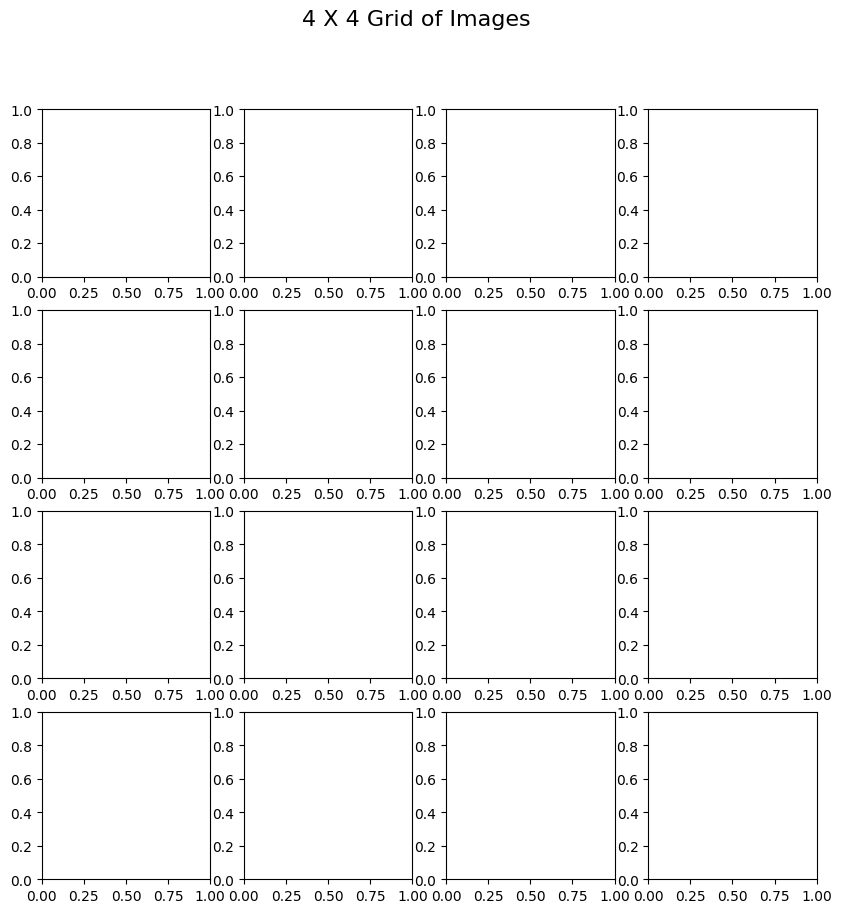

In [7]:
#create a 4 X4 grid
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('4 X 4 Grid of Images', fontsize=16)

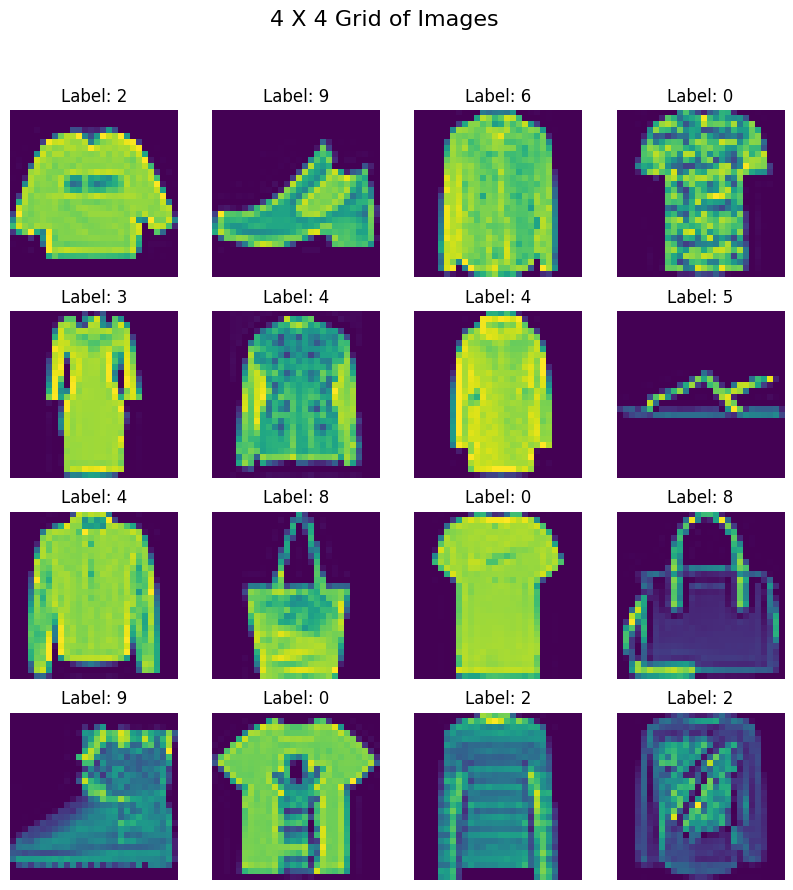

In [8]:
#create a 4 X4 grid
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('4 X 4 Grid of Images', fontsize=16)

#plot the first 16 imahes from the dataset

for i, ax in enumerate(axes.flat):
  img =df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f'Label: {df.iloc[i,0]}')
plt.show()

In [9]:
#train test split
X =df.iloc[:,1:].values
y = df.iloc[:,0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
df.iloc[:,1:]

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,5,0,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,1,2,0,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,0,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,0,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
df.iloc[:,0]

,label
0,2
1,9
2,6
3,0
4,3
...,...
59995,9
59996,1
59997,8
59998,8


In [18]:
X_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0]])

In [19]:
X_test

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ..., 211, 102,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]])

In [20]:
y_test

array([7, 8, 8, ..., 9, 5, 5])

In [21]:
y_train

array([5, 7, 8, ..., 9, 4, 0])

In [22]:
#scaling
X_train = X_train/255.0
X_test = X_test/255.0

In [23]:
#create custome class
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index], self.labels[index]

In [24]:
#create train and test dataset obejct
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [25]:
len(train_dataset)

48000

In [26]:
len(test_dataset)

12000

In [27]:
#create train and test laoder
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [29]:
#deinfe NN CLASS
class myNN(nn.Module):
  def __init__(self, input_features):
    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(input_features, out_channels=32, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),


        nn.Conv2d(32, out_channels=64, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2),

    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7, 128), #shape and size of them images depends on the architecutre and need to be calculated
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(64, 10)
    )
  def forward(self,X):
    X = self.features(X)
    X = self.classifier(X)
    return X


In [30]:
#set lr and epoch
epochs = 100
learning_rate = 0.1


In [32]:
#instancitai model and loss func and optmizer
model = myNN(1)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [33]:
#TRAIN LOOP

for epoch in range(epochs):
  total_epoch_loss =0
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward
    predicton = model(batch_features)

    #calcualte loss
    loss = criterion(predicton, batch_labels)
    #backpass
    optimizer.zero_grad() # gradient clear
    loss.backward()# gradient calucatesd

    #upadte param with newly callcauted gradients
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')


Epoch [1/100], Loss: 0.5820
Epoch [2/100], Loss: 0.4007
Epoch [3/100], Loss: 0.3451
Epoch [4/100], Loss: 0.3082
Epoch [5/100], Loss: 0.2819
Epoch [6/100], Loss: 0.2616
Epoch [7/100], Loss: 0.2442
Epoch [8/100], Loss: 0.2303
Epoch [9/100], Loss: 0.2142
Epoch [10/100], Loss: 0.2067
Epoch [11/100], Loss: 0.1958
Epoch [12/100], Loss: 0.1890
Epoch [13/100], Loss: 0.1809
Epoch [14/100], Loss: 0.1710
Epoch [15/100], Loss: 0.1684
Epoch [16/100], Loss: 0.1625
Epoch [17/100], Loss: 0.1568
Epoch [18/100], Loss: 0.1496
Epoch [19/100], Loss: 0.1488
Epoch [20/100], Loss: 0.1397
Epoch [21/100], Loss: 0.1368
Epoch [22/100], Loss: 0.1336
Epoch [23/100], Loss: 0.1304
Epoch [24/100], Loss: 0.1254
Epoch [25/100], Loss: 0.1247
Epoch [26/100], Loss: 0.1191
Epoch [27/100], Loss: 0.1216
Epoch [28/100], Loss: 0.1151
Epoch [29/100], Loss: 0.1205
Epoch [30/100], Loss: 0.1122
Epoch [31/100], Loss: 0.1088
Epoch [32/100], Loss: 0.1070
Epoch [33/100], Loss: 0.1016
Epoch [34/100], Loss: 0.1019
Epoch [35/100], Loss: 0

In [34]:
#Eval
model.eval()

myNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [37]:
#eval calcualtion
total =0
correct =0
with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward
    ouputs = model(batch_features)
    predicted = torch.argmax(ouputs, dim=1)

    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(accuracy)

0.9194166666666667


In [41]:
#eval calcualtion
total =0
correct =0
with torch.no_grad():
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward
    ouputs = model(batch_features)
    predicted = torch.argmax(ouputs, dim=1)

    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(accuracy)

0.9899791666666666
